<a href="https://colab.research.google.com/github/jaison-leonardo/data-science/blob/main/Taxi_trip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

In [2]:
drive.mount('/content/drive')
path = "/content/drive/MyDrive/Colab Notebooks/Big data files/taxi_trip/train.csv"
taxi = pd.read_csv(path)

Mounted at /content/drive


In [3]:
# Analísis exploratorio
taxi.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [4]:
taxi.shape

(1458644, 11)

In [5]:
taxi.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='object')

In [6]:
taxi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [7]:
taxi.isnull().sum()

,0
id,0
vendor_id,0
pickup_datetime,0
dropoff_datetime,0
passenger_count,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
store_and_fwd_flag,0


Distribución de las tarifas (duración del viaje)

In [9]:
taxi["trip_duration"].describe()

,trip_duration
count,1.458644e+06
mean,9.594923e+02
std,5.237432e+03
min,1.000000e+00
25%,3.970000e+02
50%,6.620000e+02
75%,1.075000e+03
max,3.526282e+06


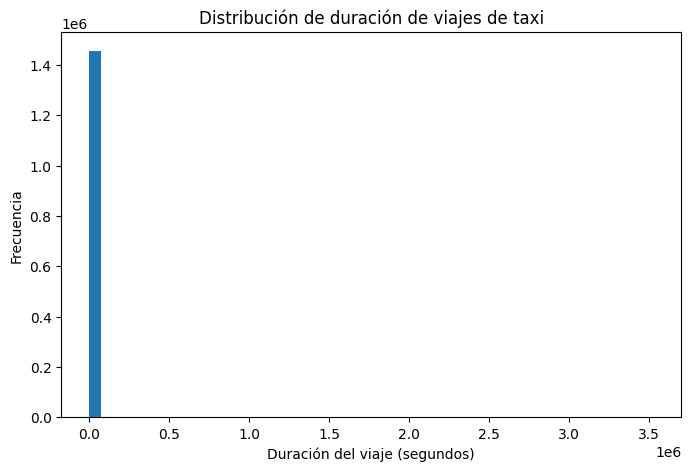

In [10]:
# Distribución de los viajes
plt.figure(figsize=(8,5))
plt.hist(taxi["trip_duration"], bins=50)
plt.title("Distribución de duración de viajes de taxi")
plt.xlabel("Duración del viaje (segundos)")
plt.ylabel("Frecuencia")
plt.show()

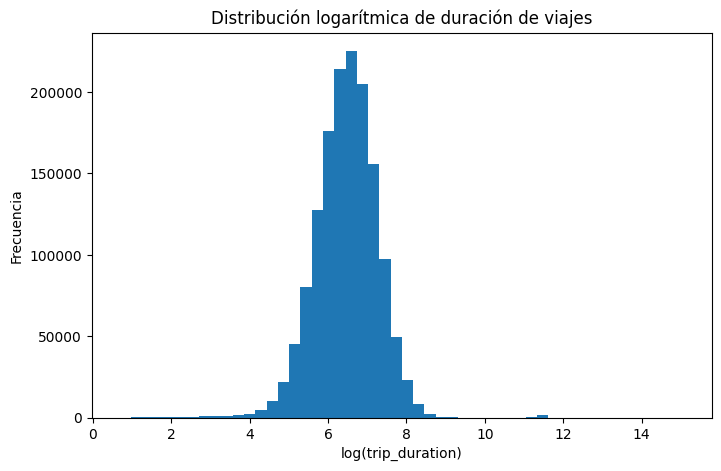

In [11]:
# Escala logaritmica para visualizar mejor
plt.figure(figsize=(8,5))
plt.hist(np.log1p(taxi["trip_duration"]), bins=50)
plt.title("Distribución logarítmica de duración de viajes")
plt.xlabel("log(trip_duration)")
plt.ylabel("Frecuencia")
plt.show()

In [14]:
# Se nota que existen outliers, viajes de mayor a 40 días
# Eliminamos valores extremos
Q1 = taxi["trip_duration"].quantile(0.25)
Q3 = taxi["trip_duration"].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
lower_bound, upper_bound

# Filtramos los datos
taxi_clean = taxi[
    (taxi["trip_duration"] >= lower_bound) &
    (taxi["trip_duration"] <= upper_bound)
]
# Verifiquemos los datos resultantes
taxi.shape, taxi_clean.shape

((1458644, 12), (1384424, 12))

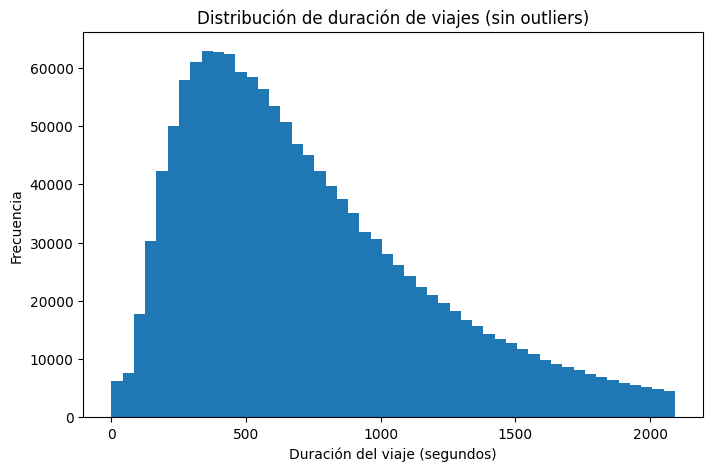

In [15]:
# Nueva distribución
plt.figure(figsize=(8,5))
plt.hist(taxi_clean["trip_duration"], bins=50)
plt.title("Distribución de duración de viajes (sin outliers)")
plt.xlabel("Duración del viaje (segundos)")
plt.ylabel("Frecuencia")
plt.show()

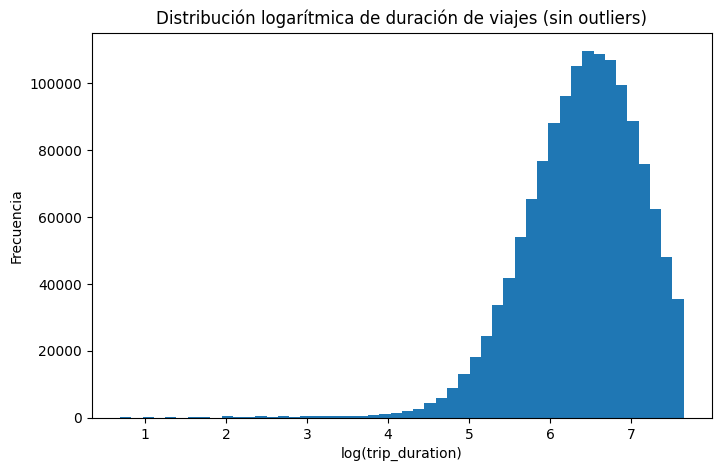

In [16]:
# Nueva escala logaritmica
plt.figure(figsize=(8,5))
plt.hist(np.log1p(taxi_clean["trip_duration"]), bins=50)
plt.title("Distribución logarítmica de duración de viajes (sin outliers)")
plt.xlabel("log(trip_duration)")
plt.ylabel("Frecuencia")
plt.show()

Variación de viajes a lo largo de las horas del día

In [17]:
# conversión del tipo de dato
taxi["pickup_datetime"] = pd.to_datetime(taxi["pickup_datetime"])
taxi["pickup_hour"] = taxi["pickup_datetime"].dt.hour

# Cuantos viajes ocurren por hora
trips_by_hour_clean = taxi_clean.groupby("pickup_hour").size()
trips_by_hour_clean

,0
pickup_hour,
0,51740
1,37771
2,27515
3,20582
4,15518
5,14547
6,31900
7,53252
8,63804


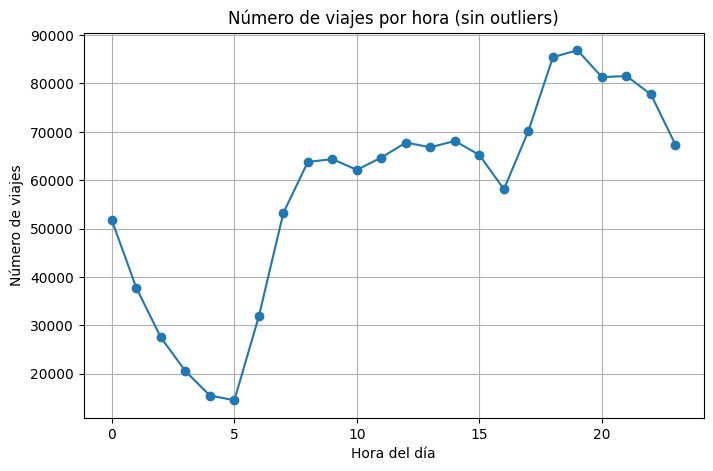

In [18]:
plt.figure(figsize=(8,5))
trips_by_hour_clean.plot(kind="line", marker="o")
plt.title("Número de viajes por hora (sin outliers)")
plt.xlabel("Hora del día")
plt.ylabel("Número de viajes")
plt.grid(True)
plt.show()